# Performance Analysis and Validation of Power Amplifier (PA) Performance in Relation to the IQ Modulator (IQM)

In [36]:
import numpy as np
from scipy import signal
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter

from matplotlib.lines import Line2D

In [37]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

## Defining the Power Amplifier (PA) Functions

In [38]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Power Amplifier (PA) Functions
# ---------------------------------------------------------------------------------------------------------------------------------------

def rapp_pa(x, Vsat, p=2.0):
    """
    Memoryless Rapp PA model for complex baseband input.

    Parameters
    ----------
    x : np.ndarray
        Complex input waveform in volts.
    Vsat : float
        Saturation voltage/amplitude.
    p : float
        Rapp smoothness exponent.

    Returns
    -------
    y : np.ndarray
        Output after memoryless PA nonlinearity.
    """
    mag = np.abs(x)
    gain = 1.0 / (1.0 + (mag / Vsat) ** (2 * p)) ** (1.0 / (2 * p))
    return x * gain


def butter_lpf_complex(x, Fs, f3dB, order=3):
    """
    Apply an order-N Butterworth LPF to a complex baseband waveform.
    """
    wn = f3dB / (Fs / 2)

    if wn >= 1.0:
        raise ValueError(
            f"Butterworth cutoff must be below Nyquist. Got f3dB={f3dB/1e9:.2f} GHz, "
            f"Fs/2={(Fs/2)/1e9:.2f} GHz."
        )

    b, a = signal.butter(order, wn, btype='low')

    y_i = signal.lfilter(b, a, np.real(x))
    y_q = signal.lfilter(b, a, np.imag(x))

    return y_i + 1j * y_q


def pa_model_physical(x, Fs, gain_linear, BLPF_enable, BO_dB=5.0, p=2.0, f3dB=10e9, order=3):
    """
    Physical PA model:
        x -> linear gain -> Rapp compression -> Butterworth LPF

    Parameters
    ----------
    x : np.ndarray
        Complex baseband input waveform (dimensionless DSP waveform).
    Fs : float
        Sample rate [Hz].
    gain_linear : float
        Small-signal linear voltage gain. This sets the nominal IQM drive level.
    BO_dB : float
        Back-off in dB, used to set Vsat relative to the RMS value AFTER gain.
    p : float
        Rapp exponent.
    f3dB : float
        PA 3-dB bandwidth [Hz].
    order : int
        Butterworth filter order.

    Returns
    -------
    y : np.ndarray
        PA output waveform in volts, ready to drive the IQM.
    info : dict
        Diagnostic information.
    """

    # 1) Linear gain stage -> now waveform is in volts
    x_amp = gain_linear * x

    # 2) Compute RMS after gain
    Vrms_in = np.sqrt(np.mean(np.abs(x_amp) ** 2))

    # 3) Saturation voltage from back-off
    Vsat = Vrms_in * 10 ** (BO_dB / 20)

    # 4) Nonlinear compression
    y_nl = rapp_pa(x_amp, Vsat=Vsat, p=p)

    # 5) PA bandwidth limitation
    if BLPF_enable:
        y = butter_lpf_complex(y_nl, Fs=Fs, f3dB=f3dB, order=order)
    else:
        y = y_nl

    info = {
        "gain_linear": gain_linear,
        "Vrms_in_V": Vrms_in,
        "Vsat_V": Vsat,
        "BO_dB": BO_dB,
        "p": p,
        "f3dB_Hz": f3dB,
        "peak_out_V": np.max(np.abs(y)),
        "rms_out_V": np.sqrt(np.mean(np.abs(y) ** 2)),
    }

    return y, info

## Optical System Parameter Configuration

In [39]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Parameters Configuration of Optical System
# ---------------------------------------------------------------------------------------------------------------------------------------


# -----------------------------------------------
# Transmitter Parameters
#-------------------------------------------------

# 1) General Parameters
SpS = 16                 # samples per symbol
Rs = 32e9                # symbol rate [baud]
Fs = Rs * SpS            # sampling frequency [Hz]
M = 16                   # QAM -> M=16, constType='qam'
nBits = 400000           # total bits to generate
rollOff = 0.01           # RRC roll-off
nFilterTaps = 1024       # RRC filter taps
mzmScale = 1           # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
Vpi = 2                  # IQM pi Voltage  (2V is defualt in OpticommPy)
P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
laserLinewidth = 0       # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 

# 2) Symbol Source Parameters
paramSymb = parameters()
paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
paramSymb.M = M
paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
paramSymb.dist = "uniform"                     # uniform symbol probabilities
paramSymb.seed = 444
paramSymb.shapingFactor = 0

constSymb = grayMapping(paramSymb.M, paramSymb.constType)
if paramSymb.dist == "uniform":
   px = np.ones(paramSymb.M) / paramSymb.M
elif paramSymb.dist == "maxwell-boltzmann":
   px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
   px = px / np.sum(px)
else:
   raise ValueError("Invalid probability distribution.")
paramSymb.px = px

# 3) UpSampling and FIR Parameters
paramPulse = parameters()
paramPulse.pulseType = "rrc"
paramPulse.nFilterTaps = nFilterTaps
paramPulse.rollOff = rollOff
paramPulse.SpS = SpS

# 4) IQM Parameters
paramIQM = parameters()
paramIQM.Vpi = Vpi
paramIQM.VbI = -Vpi
paramIQM.VbQ = -Vpi
paramIQM.Vphi = Vpi/2

# 5) Optical Carrier / LO field (Ein)
sigTx_length = paramSymb.nSymbols * SpS
if laserLinewidth and laserLinewidth > 0:
    phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=123)
    sigLO = np.exp(1j * phi_pn)
else:
    sigLO = np.ones(sigTx_length, dtype=complex)

# 6) PA parameters 
PA_enable = True    # enable flag. If "False", the PA is skipped
PA_BO_dB = 5        # 7 = weak, 5 = moderate, 3 = strong
PA_p = 2.0           # paper says typically p=2
PA_f3dB = 18.5e9     # frequency of 3 dB
BLPF_enable = True

# -----------------------------------------------
# Receiver Parameters
#------------------------------------------------

# 1) local oscillator (LO) parameters:
FO  = 0                # frequency offset
paramLO = parameters()
paramLO.P = 10              # power in dBm
paramLO.lw = 0         # laser linewidth
paramLO.RIN_var = 0
paramLO.Fs = Fs
paramLO.seed = 789 # random seed for noise generation
paramLO.freqShift = 0 + FO  # downshift of the channel to be demodulated add frequency offset

# 2) Front-End Parameters and photodiode paramters

# Frontend parameters
paramFE = parameters()
paramFE.Fs = Fs

# Photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fs
paramPD.ideal = True
paramPD.seed = 1011

# 3) Pulseshaping in the reciever using rrc filter
paramRxPulse = parameters()
paramRxPulse.SpS = SpS
paramRxPulse.nFilterTaps = nFilterTaps
paramRxPulse.rollOff = rollOff
paramRxPulse.pulseType = "rrc"

# 4) Decimation Parameters
paramDec = parameters()
paramDec.SpSin  = SpS
paramDec.SpSout = 1

In [40]:
def simulate_optical_system(symbTx, paramSymb, paramPulse, paramIQM, sigLO, paramLO, paramFE, paramPD, paramRxPulse, paramDec, mzmScale, BLPF_enable):

    """
    Simulates the optical transmission of a single-polarization, single-channel QAM signal.

    Returns
    -------
    u_drive :
        Electrical PA output in volts applied directly to the IQM
    sigTx :
        Pulse-shaped DSP waveform before PA
    sigTxo :
        Optical transmitted signal
    sigRxPulseShape :
        Received signal after matched filtering
    sigRxDecimation :
        Received signal after decimation
    paInfo :
        PA diagnostics
    """

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # TRANSMITTER

    # 1) Upsampling + pulse shaping
    pulse = pulseShape(paramPulse)
    symbolsUp = upsample(symbTx, SpS)
    sigTx = firFilter(pulse, symbolsUp)

    # 2) Choose nominal small-signal PA gain so the nominal drive is around mzmScale * Vpi
    target_peak_V = mzmScale * Vpi
    peak_sigTx = np.max(np.abs(sigTx))

    if peak_sigTx == 0:
        raise ValueError("sigTx peak is zero; cannot set PA gain.")

    gain_linear = target_peak_V / peak_sigTx

    # 3) Driver amplifier / PA output directly in volts
    if PA_enable:
        u_drive, paInfo = pa_model_physical(
            sigTx,
            Fs=Fs,
            gain_linear=gain_linear,
            BLPF_enable = BLPF_enable,
            BO_dB=PA_BO_dB,
            p=PA_p,
            f3dB=PA_f3dB,
            order=3
        )
    else:
        u_drive = gain_linear * sigTx
        paInfo = {
            "gain_linear": gain_linear,
            "Vrms_in_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
            "Vsat_V": None,
            "BO_dB": None,
            "p": None,
            "f3dB_Hz": None,
            "peak_out_V": np.max(np.abs(u_drive)),
            "rms_out_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
        }

    # 4) IQ modulation: PA output drives the IQM directly
    sigTxo = iqm(sigLO, u_drive, paramIQM)

    # 5) Set launched optical power
    P_launch_W = dBm2W(P_launch_dBm)
    sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # RECEIVER

    # 1) Generate CW laser LO field
    paramLO.Ns = len(sigTxo)
    sigLO_Rx = basicLaserModel(paramLO)

    # 2) Coherent receiver
    sigRxFrontEnd = coherentReceiver(sigTxo, sigLO_Rx, paramFE, paramPD)

    # 3) Matched filtering
    pulse = pulseShape(paramRxPulse)
    sigRxPulseShape = firFilter(pulse, sigRxFrontEnd)

    # 4) Decimation
    sigRxDecimation = decimate(sigRxPulseShape, paramDec)

    return u_drive, sigTx, sigTxo, sigRxPulseShape, sigRxDecimation, paInfo

## Plot Functions to Explore and Validate Performance

In [41]:
#Plotting functions for the IQM

def plot_mzm_transfer_function_and_operating_range_of_drive_signal(u_drive):
    
    v_axis = np.linspace(-4*paramIQM.Vpi, 4*paramIQM.Vpi, 2000)
    transfer = np.cos((np.pi/(2*paramIQM.Vpi)) * v_axis)

    plt.figure(figsize=(10,5))

    plt.plot(v_axis/paramIQM.Vpi, transfer, label='MZM field transfer')
    
    plt.axvspan(np.min(u_drive.real + paramIQM.VbI)/paramIQM.Vpi, np.max(u_drive.real + paramIQM.VbI)/paramIQM.Vpi, alpha=0.25, label='I-arm operating range')
    plt.axvspan(np.min(u_drive.imag + paramIQM.VbQ)/paramIQM.Vpi, np.max(u_drive.imag + paramIQM.VbQ)/paramIQM.Vpi, alpha=0.25, label='Q-arm operating range')

    plt.axvline(paramIQM.VbI/paramIQM.Vpi,color='red', linestyle='--', linewidth=2, label='Bias point')
    plt.xlabel(r'Total branch voltage / $V_\pi$')
    plt.ylabel('Field transfer')
    plt.title('Where the drive signal operates on the MZM transfer curve')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


def plot_mzm_transfer_with_operating_regions_for_animation(u_drive_05, u_drive_10, paramIQM):
    """
    Static plot:
    - MZM transfer function
    - dashed vertical lines showing operating region limits
      for mzmScale = 0.5 and 1.0
    """

    Vpi = paramIQM.Vpi
    Vb  = paramIQM.VbI   # same bias used for both I/Q in your setup

    # Voltage axis for one clear full view
    v_axis = np.linspace(-2 * Vpi, 2 * Vpi, 2000)
    transfer = np.cos((np.pi / (2 * Vpi)) * v_axis)

    # Operating ranges using total branch voltage = u + Vb
    v05_min = np.min(u_drive_05.real + Vb)
    v05_max = np.max(u_drive_05.real + Vb)

    v10_min = np.min(u_drive_10.real + Vb)
    v10_max = np.max(u_drive_10.real + Vb)

    plt.figure(figsize=(16, 7))
    plt.plot(v_axis / Vpi, transfer, linewidth=2.5, label='MZM field transfer')

    # Bias point
    plt.axvline(Vb / Vpi, color='red', linestyle='--', linewidth=2, label='Bias point')

    # mzmScale = 0.5 region
    plt.axvline(v05_min / Vpi, color='blue', linestyle='--', linewidth=2,
                label='Operating region (mzmScale = 0.5)')
    plt.axvline(v05_max / Vpi, color='blue', linestyle='--', linewidth=2)

    # mzmScale = 1.0 region
    plt.axvline(v10_min / Vpi, color='green', linestyle='--', linewidth=2,
                label='Operating region (mzmScale = 1.0)')
    plt.axvline(v10_max / Vpi, color='green', linestyle='--', linewidth=2)

    plt.xlabel(r'Total branch voltage / $V_\pi$')
    plt.ylabel('Field transfer')
    plt.title('MZM Transfer Function with Operating Regions')
    plt.xlim(-2, 2)
    plt.ylim(-1.1, 1.1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def animate_mzm_operating_point_slow(u_drive_05, u_drive_10, paramIQM,
                                     branch='I',
                                     gif_name='mzm_operating_point_slow.gif',
                                     interval_ms=200,
                                     fps=10,
                                     n_cycles=2,
                                     n_sweep_points=300):
    """
    Plot both operating regions:
      - mzmScale = 0.5
      - mzmScale = 1.0

    Animate only one operating point:
      - for mzmScale = 1.0

    Uses a smooth synthetic sweep across the full 1.0 region,
    which looks much better and slower for presentations.
    """

    plt.rcParams.update({
    'font.size': 18,          # base font
    'axes.titlesize': 20,     # title
    'axes.labelsize': 19,     # axis labels
    'xtick.labelsize': 16,    # x ticks
    'ytick.labelsize': 16,    # y ticks
    'legend.fontsize': 16     # legend
    })

    Vpi = paramIQM.Vpi

    if branch.upper() == 'I':
        Vb = paramIQM.VbI
        swing_05 = np.real(u_drive_05) + Vb
        swing_10 = np.real(u_drive_10) + Vb
    else:
        Vb = paramIQM.VbQ
        swing_05 = np.imag(u_drive_05) + Vb
        swing_10 = np.imag(u_drive_10) + Vb

    # Region limits
    v05_min = np.min(swing_05)
    v05_max = np.max(swing_05)
    v10_min = np.min(swing_10)
    v10_max = np.max(swing_10)

    # Smooth sweep across the full mzmScale = 1.0 region
    forward = np.linspace(v10_min, v10_max, n_sweep_points)
    backward = np.linspace(v10_max, v10_min, n_sweep_points)
    one_cycle = np.concatenate([forward, backward])

    sweep = np.tile(one_cycle, n_cycles)

    def mzm_transfer(v):
        return np.cos((np.pi / (2 * Vpi)) * v)

    v_axis = np.linspace(-2 * Vpi, 2 * Vpi, 2000)
    transfer = mzm_transfer(v_axis)

    fig, ax = plt.subplots(figsize=(10, 5))

    # Main transfer curve
    ax.plot(v_axis / Vpi, transfer, color='black', linewidth=2.5, label='MZM transfer fcn')

    # Bias point
    ax.axvline(Vb / Vpi, color='red', linestyle='--', linewidth=2, label='Bias point')

    # Region for mzmScale = 0.5
    ax.axvline(v05_min / Vpi, color='blue', linestyle='--', linewidth=2,
               label='Operating region, mzmScale = 0.5')
    ax.axvline(v05_max / Vpi, color='blue', linestyle='--', linewidth=2)

    # Region for mzmScale = 1.0
    ax.axvline(v10_min / Vpi, color='green', linestyle='--', linewidth=2,
               label='Operating region, mzmScale = 1.0')
    ax.axvline(v10_max / Vpi, color='green', linestyle='--', linewidth=2)

    # Only one animated point
    point, = ax.plot([], [], 'o', markersize=11, label='Operating point')

    # Small trail
    trail, = ax.plot([], [], linewidth=2, alpha=0.7)

    ax.set_xlabel(r'Total branch voltage / $V_\pi$')
    ax.set_ylabel('Field transfer')
    ax.set_title(f'MZM Operating Point Animation ({branch.upper()} branch)')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, alpha=0.3)
    fig.subplots_adjust(bottom=0.16)

    tail = 20

    def init():
        point.set_data([], [])
        trail.set_data([], [])
        return point, trail

    def update(frame):
        x = sweep[frame] / Vpi
        y = mzm_transfer(sweep[frame])

        point.set_data([x], [y])

        start = max(0, frame - tail)
        trail.set_data(
            sweep[start:frame+1] / Vpi,
            mzm_transfer(sweep[start:frame+1])
        )

        return point, trail

    ani = FuncAnimation(
        fig,
        update,
        frames=len(sweep),
        init_func=init,
        blit=True,
        interval=interval_ms
    )

    ani.save(gif_name, writer=PillowWriter(fps=fps))
    print(f"Saved animation to: {gif_name}")

    plt.show()
    return ani

def plot_mzm_legend_only():
    fig_leg, ax_leg = plt.subplots(figsize=(14, 1.6))
    ax_leg.axis('off')
    plt.rcParams.update({
    'font.size': 18,          # base font
    'axes.titlesize': 20,     # title
    'axes.labelsize': 19,     # axis labels
    'xtick.labelsize': 16,    # x ticks
    'ytick.labelsize': 16,    # y ticks
    'legend.fontsize': 16     # legend
    })

    handles = [
        Line2D([0], [0], color='black', lw=2.5, label='MZM transfer'),
        Line2D([0], [0], color='red', lw=2, ls='--', label='Bias'),
        Line2D([0], [0], color='blue', lw=1.8, ls='--', label='mzmScale = 0.5'),
        Line2D([0], [0], color='green', lw=1.8, ls='--', label='mzmScale = 1.0'),
        Line2D([0], [0], marker='o', linestyle='None', markersize=8, label='Point')
    ]

    ax_leg.legend(
        handles=handles,
        loc='center',
        ncol=5,
        frameon=True,
        framealpha=1.0,
        edgecolor='black'
    )

    plt.tight_layout()
    plt.savefig("mzm_legend.png", dpi=300, bbox_inches='tight', transparent=True)

    plt.show()


# def plot_mzm_transfer_function_and_operating_range_of_drive_signal(u_drive, filename=None):
    
#     v_axis = np.linspace(-2*paramIQM.Vpi, 2*paramIQM.Vpi, 1000)
#     transfer = np.cos((np.pi/(2*paramIQM.Vpi)) * v_axis)

#     plt.figure(figsize=(7,3.5))

#     plt.plot(v_axis/paramIQM.Vpi, transfer, label='MZM field transfer')
    
#     vI = u_drive.real + paramIQM.VbI
#     vQ = u_drive.imag + paramIQM.VbQ

#     plt.axvspan(np.min(vI)/paramIQM.Vpi, np.max(vI)/paramIQM.Vpi,
#                 alpha=0.25, label='I-arm range')
    
#     plt.axvspan(np.min(vQ)/paramIQM.Vpi, np.max(vQ)/paramIQM.Vpi,
#                 alpha=0.25, label='Q-arm range')

#     plt.axvline(paramIQM.VbI/paramIQM.Vpi,
#                 color='red', linestyle='--', linewidth=2, label='Bias point')

#     plt.xlabel(r'Voltage / $V_\pi$')
#     plt.ylabel('Field transfer')
#     plt.title('MZM transfer function (one full period)')
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# def plot_mzm_comparison(u_drive_1, u_drive_05):

#     v_axis = np.linspace(-2*paramIQM.Vpi, 2*paramIQM.Vpi, 1000)
#     transfer = np.cos((np.pi/(2*paramIQM.Vpi)) * v_axis)

#     plt.figure(figsize=(10,4))

#     # ---------- LEFT: mzmScale = 1 ----------
#     plt.subplot(1,2,1)

#     plt.plot(v_axis/paramIQM.Vpi, transfer, label='MZM transfer')

#     vI = u_drive_1.real + paramIQM.VbI
#     vQ = u_drive_1.imag + paramIQM.VbQ

#     plt.axvspan(np.min(vI)/paramIQM.Vpi, np.max(vI)/paramIQM.Vpi,
#                 alpha=0.25, color='blue', label='I-arm')
#     plt.axvspan(np.min(vQ)/paramIQM.Vpi, np.max(vQ)/paramIQM.Vpi,
#                 alpha=0.25, color='orange', label='Q-arm')

#     plt.axvline(paramIQM.VbI/paramIQM.Vpi,
#                 color='red', linestyle='--', linewidth=2, label='Bias')

#     plt.title('mzmScale = 1')
#     plt.xlabel(r'Voltage / $V_\pi$')
#     plt.ylabel('Field transfer')
#     plt.grid(True)

#     # ---------- RIGHT: mzmScale = 0.5 ----------
#     plt.subplot(1,2,2)

#     plt.plot(v_axis/paramIQM.Vpi, transfer)

#     vI = u_drive_05.real + paramIQM.VbI
#     vQ = u_drive_05.imag + paramIQM.VbQ

#     plt.axvspan(np.min(vI)/paramIQM.Vpi, np.max(vI)/paramIQM.Vpi,
#                 alpha=0.25, color='blue')
#     plt.axvspan(np.min(vQ)/paramIQM.Vpi, np.max(vQ)/paramIQM.Vpi,
#                 alpha=0.25, color='orange')

#     plt.axvline(paramIQM.VbI/paramIQM.Vpi,
#                 color='red', linestyle='--', linewidth=2)

#     plt.title('mzmScale = 0.5')
#     plt.xlabel(r'Voltage / $V_\pi$')
#     plt.grid(True)

#     # ---------- FORCE IDENTICAL AXES ----------
#     for ax in plt.gcf().axes:
#         ax.set_xlim(-2, 2)
#         ax.set_ylim(-1.1, 1.1)

#     # ---------- SINGLE LEGEND ----------
#     plt.subplot(1,2,1)
#     plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4)

#     plt.tight_layout()
#     plt.show()


def plot_histogram_of_IQM_branches(u_drive):  

    xI = (u_drive.real + paramIQM.VbI)/paramIQM.Vpi
    xQ = (u_drive.imag + paramIQM.VbQ)/paramIQM.Vpi

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(xI, bins=100, density=True)
    plt.title("I branch normalized voltage")
    plt.xlabel("(uI+VbI)/Vpi")

    plt.subplot(1,2,2)
    plt.hist(xQ, bins=100, density=True)
    plt.title("Q branch normalized voltage")
    plt.xlabel("(uQ+VbQ)/Vpi")

    plt.tight_layout()
    plt.show()

def EVM_vs_mzmScale_plot(mzmScale_list, EVM_list):
    plt.figure(figsize=(7,4))
    plt.plot(mzmScale_list, np.array(EVM_list)*100, 'o-', linewidth=2)
    plt.xlabel('mzmScale')
    plt.ylabel('EVM [%]')
    plt.title('Tx-side EVM vs IQM modulation depth')
    plt.grid(True)
    plt.tight_layout()
    plt.show()  

def plot_am_am(u_drive, sigTx, sigTxo, PA_enable):
    if PA_enable:
        amp_in = np.abs(u_drive)
        amp_out = np.abs(sigTxo)
    else:
        amp_in = np.abs(sigTx)
        amp_out = np.abs(sigTxo)

    plt.figure(figsize=(6,5))
    plt.scatter(amp_in, amp_out, s=2, alpha=0.3)
    plt.xlabel("Input amplitude |s(t)|")
    plt.ylabel("Output optical amplitude |E(t)|")
    plt.title("AM-AM distortion (Tx nonlinearity)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_am_am_comparison(u_drive_1, sigTx_1, sigTxo_1,
                         u_drive_2, sigTx_2, sigTxo_2,
                         PA_enable,
                         label1="Case 1", label2="Case 2"):

    # GLOBAL STYLE (bigger + clean)
    plt.rcParams.update({
        'font.size': 18,
        'axes.titlesize': 18,
        'axes.labelsize': 18,
        'legend.fontsize': 14,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13
    })

    fig, ax = plt.subplots(1, 2, figsize=(14,6), sharey=True)

    # ---- CASE 1 ----
    amp_in_1 = np.abs(u_drive_1) if PA_enable else np.abs(sigTx_1)
    amp_out_1 = np.abs(sigTxo_1)

    ax[0].scatter(amp_in_1, amp_out_1, s=5, alpha=1.0, color='blue')
    ax[0].set_title(label1, fontsize=18)
    ax[0].set_xlabel("Input amplitude |u(t)|")
    ax[0].set_ylabel("Output optical amplitude |E(t)|")
    ax[0].grid(True)

    # 🔧 Fewer ticks (clean look)
    ax[0].locator_params(nbins=5)

    # ---- CASE 2 ----
    amp_in_2 = np.abs(u_drive_2) if PA_enable else np.abs(sigTx_2)
    amp_out_2 = np.abs(sigTxo_2)

    ax[1].scatter(amp_in_2, amp_out_2, s=5, alpha=1.0, color='blue')
    ax[1].set_title(label2, fontsize=18)
    ax[1].set_xlabel("Input amplitude |u(t)|")
    ax[1].grid(True)

    # 🔧 Fewer ticks
    ax[1].locator_params(nbins=5)

    # Better spacing for big title
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("amam_comparison.png", dpi=300, bbox_inches="tight")

    plt.show()

## Function to Print Metrics for Performance Evaluation

In [42]:
def print_tx_metrics(sigTx, u_drive, sigTxo, paramIQM, mzmScale, EVM, paInfo=None):
    """
    Minimal Tx-side validation metrics for the IQM transmitter.
    """

    print("\n===== TX VALIDATION =====\n")

    peak_sigTx = np.max(np.abs(sigTx))
    rms_sigTx = np.sqrt(np.mean(np.abs(sigTx)**2))

    print(f"Peak |sigTx| before PA    : {peak_sigTx:.6f}")
    print(f"RMS  |sigTx| before PA    : {rms_sigTx:.6f}")

    target_peak_V = mzmScale * paramIQM.Vpi
    peak_rf_drive = np.max(np.abs(u_drive)) / paramIQM.Vpi

    print(f"Nominal target peak [V]   : {target_peak_V:.3f}")
    print(f"Actual peak |u_drive| [V] : {np.max(np.abs(u_drive)):.3f}")
    print(f"Peak RF drive / Vpi       : {peak_rf_drive:.3f}")

    vI_norm = (u_drive.real + paramIQM.VbI) / paramIQM.Vpi
    vQ_norm = (u_drive.imag + paramIQM.VbQ) / paramIQM.Vpi

    print(f"I voltage range / Vpi     : [{np.min(vI_norm):.3f} , {np.max(vI_norm):.3f}]")
    print(f"Q voltage range / Vpi     : [{np.min(vQ_norm):.3f} , {np.max(vQ_norm):.3f}]")

    max_norm_total = max(np.max(np.abs(vI_norm)), np.max(np.abs(vQ_norm)))
    print(f"Max |(u+Vb)/Vpi|          : {max_norm_total:.3f}")

    opt_power = np.abs(sigTxo) ** 2
    mean_opt_power = np.mean(opt_power)
    print(f"Mean optical power        : {mean_opt_power:.4e}")

    if paInfo is not None:
        print(f"PA gain_linear            : {paInfo['gain_linear']:.4f}")
        if paInfo["BO_dB"] is not None:
            print(f"PA BO_dB                  : {paInfo['BO_dB']:.2f}")
        if paInfo["Vsat_V"] is not None:
            print(f"PA Vsat [V]               : {paInfo['Vsat_V']:.4f}")
        print(f"PA output RMS [V]         : {paInfo['rms_out_V']:.4f}")

    print('EVM                       : %.3f %%' % (EVM[0] * 100))

    print("\n=========================\n")

## EVM Calculation Function

In [43]:
def evm_calc(symbTx, received):
    discard = 5000
    ind = np.arange(discard, len(symbTx) - discard)
    d = symbTx

    # now compute metrics (both are 1 sample/symbol and same length)
    EVM = calcEVM(received[ind], M, 'qam', d[ind])

    return EVM
   

## Impact of MZM Scale Factor on IQ Modulator (IQM) Nonlinear Distortion via PA Functions

mzmScale Sweep:   0%|          | 0/2 [00:00<?, ?it/s]

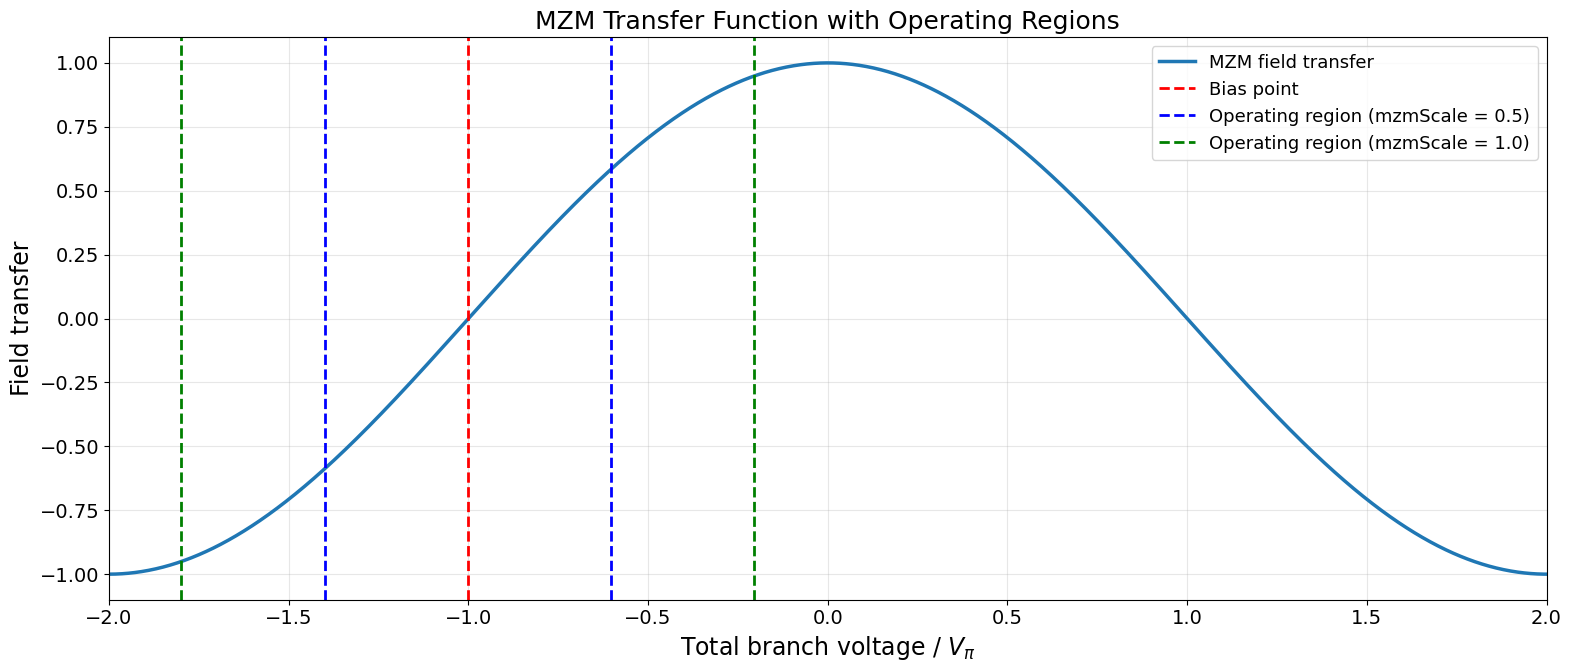

Animation.save using <class 'matplotlib.animation.PillowWriter'>


Saved animation to: mzm_operating_point_very_slow.gif


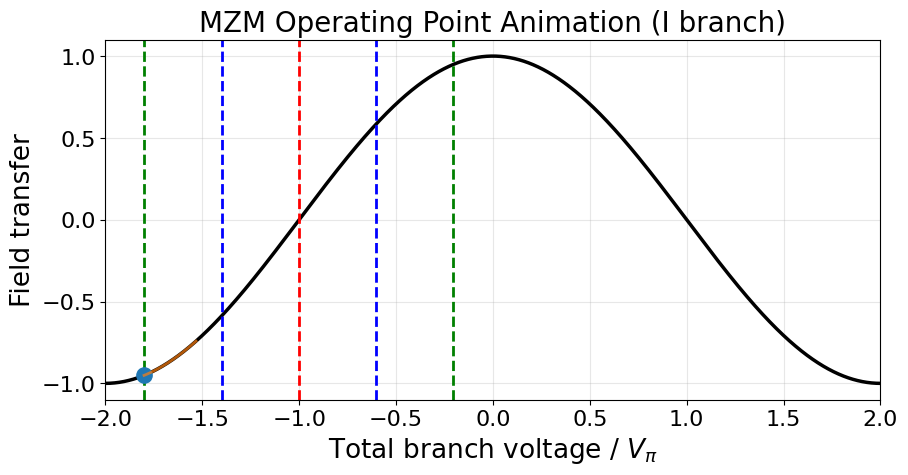

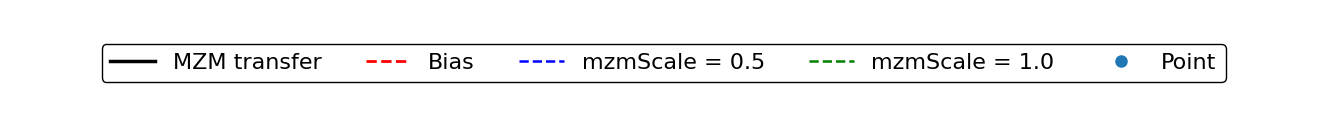

In [44]:
symbTx = symbolSource(paramSymb)

EVM_list = []
PA_enable = False

# store comparison cases
case_05 = {}
case_10 = {}

mzmScale_list = [0.25, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3]
mzmScale_list = [0.5, 1.0]

for mzmScale_value in tqdm(mzmScale_list, desc="mzmScale Sweep"):

    mzmScale = mzmScale_value

    u_drive, sigTx, sigTxo, matched, received, paInfo = simulate_optical_system(
        symbTx, paramSymb, paramPulse, paramIQM, sigLO,
        paramLO, paramFE, paramPD, paramRxPulse,
        paramDec, mzmScale, BLPF_enable
    )

    # store full cases for later comparison
    if mzmScale == 0.5:
        case_05 = {
            "u_drive": u_drive,
            "sigTx": sigTx,
            "sigTxo": sigTxo
        }
    elif mzmScale == 1.0:
        case_10 = {
            "u_drive": u_drive,
            "sigTx": sigTx,
            "sigTxo": sigTxo
        }


plot_mzm_transfer_with_operating_regions_for_animation(
    case_05["u_drive"],
    case_10["u_drive"],
    paramIQM
)

ani = animate_mzm_operating_point_slow(
    case_05["u_drive"],
    case_10["u_drive"],
    paramIQM,
    branch='I',
    gif_name='mzm_operating_point_very_slow.gif',
    interval_ms= 70,
    fps=10,
    n_cycles=1,
    n_sweep_points=120
)

plot_mzm_legend_only()

    #plot_mzm_transfer_function_and_operating_range_of_drive_signal(u_drive)

    # EVM = evm_calc(symbTx, received)
    # EVM_list.append(EVM)

    #plot_am_am(u_drive, sigTx, sigTxo, PA_enable)

    #discard = 5000
    #pconst(received[discard:-discard])

   # print_tx_metrics(sigTx, u_drive, sigTxo, paramIQM, mzmScale, EVM, paInfo)

# compare MZM operating regions
# plot_mzm_comparison(case_10["u_drive"], case_05["u_drive"])

# compare AM-AM side by side
# plot_am_am_comparison(
#     case_05["u_drive"], case_05["sigTx"], case_05["sigTxo"],
#     case_10["u_drive"], case_10["sigTx"], case_10["sigTxo"],
#     PA_enable=PA_enable,
#     label1="mzmScale = 0.5",
#     label2="mzmScale = 1.0"
# )

# for i in range(len(EVM_list)):
#     print('EVM: %.3f %%' % (EVM_list[i][0] * 100))

# EVM_vs_mzmScale_plot(mzmScale_list, EVM_list)


## Impact of the PA Butterworth Filter on PSD: Bandwidth Limitation and Non-Uniform Signal Attenuation

In [ ]:
# mzmScale = 1.5
# BLPF_enable = False
# u_drive_noLPF, sigTx, sigTxo, matched, received, paInfo= simulate_optical_system(symbTx, paramSymb, paramPulse, paramIQM, sigLO, paramLO, paramFE, paramPD,paramRxPulse, paramDec, mzmScale, BLPF_enable)

# BLPF_enable = True
# u_drive_LPF, sigTx, sigTxo, matched, received, paInfo = simulate_optical_system(symbTx, paramSymb, paramPulse, paramIQM, sigLO, paramLO, paramFE, paramPD,paramRxPulse, paramDec, mzmScale, BLPF_enable)

# fig, ax = plt.subplots(2, 1, figsize=(12,6), sharex=True)

# # --- WITHOUT Butterworth ---
# ax[0].psd(sigTx, Fs=Fs, NFFT=16*1024, sides='twosided', label='Before PA')
# ax[0].psd(u_drive_noLPF, Fs=Fs, NFFT=16*1024, sides='twosided', label='After PA (no LPF)')
# ax[0].set_title("PSD without Butterworth bandwidth limitation")
# ax[0].set_xlim(-40e9, 40e9)
# ax[0].set_ylim(-200, -80)
# ax[0].grid(True)
# ax[0].legend()

# # --- WITH Butterworth ---
# ax[1].psd(sigTx, Fs=Fs, NFFT=16*1024, sides='twosided', label='Before PA')
# ax[1].psd(u_drive_LPF, Fs=Fs, NFFT=16*1024, sides='twosided', label='After PA (Butterworth LPF)')
# ax[1].axvline(PA_f3dB, color='red', linestyle='--', label='PA f3dB')
# ax[1].axvline(-PA_f3dB, color='red', linestyle='--')
# ax[1].set_title("PSD with Butterworth bandwidth limitation")
# ax[1].set_xlim(-40e9, 40e9)
# ax[1].set_ylim(-200, -80)
# ax[1].grid(True)
# ax[1].legend()

# plt.xlabel("Frequency (Hz)")
# plt.tight_layout()
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt

# # --- Global styling (important for Word) ---
# plt.rcParams.update({
#     'font.size': 15,
#     'axes.titlesize': 17,
#     'axes.labelsize': 16,
#     'legend.fontsize': 14,
#     'xtick.labelsize': 14,
#     'ytick.labelsize': 14
# })

# fig, ax = plt.subplots(figsize=(10, 5))

# # PSD plots (thicker lines)
# ax.psd(sigTx, Fs=Fs, NFFT=16*1024, sides='twosided',
#        linewidth=2.0, label='Before PA')

# ax.psd(u_drive_noLPF, Fs=Fs, NFFT=16*1024, sides='twosided',
#        linewidth=2.0, label='After PA (no LPF)')

# ax.psd(u_drive_LPF, Fs=Fs, NFFT=16*1024, sides='twosided',
#        linewidth=2.2, label='After PA (LPF)')

# # PA bandwidth markers (clearer)
# ax.axvline(PA_f3dB, color='red', linestyle='--', linewidth=2.0, label='PA f3dB')
# ax.axvline(-PA_f3dB, color='red', linestyle='--', linewidth=2.0)

# # Labels
# ax.set_xlabel("Frequency (Hz)")
# ax.set_ylabel("PSD (dB/Hz)")

# # Limits
# ax.set_xlim(-40e9, 40e9)
# ax.set_ylim(-200, -80)

# # Grid (lighter, cleaner)
# ax.grid(True, alpha=0.3)

# # Legend (top-left, boxed, clear)
# ax.legend(loc='upper left',
#           frameon=True,
#           framealpha=1.0,
#           edgecolor='black')

# plt.tight_layout()

# # Save high-quality
# plt.savefig("butterworth_psd_clean.png", dpi=600, bbox_inches='tight')
# # plt.savefig("butterworth_psd_clean.pdf", bbox_inches='tight')

# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Global styling for report / Word ---
# plt.rcParams.update({
#     'font.size': 15,
#     'axes.titlesize': 17,
#     'axes.labelsize': 16,
#     'legend.fontsize': 14,
#     'xtick.labelsize': 14,
#     'ytick.labelsize': 14
# })

# # ------------------------------------------------------------
# # AM/AM curve of the PA for different back-off values
# # ------------------------------------------------------------

# # Input amplitude sweep
# Ain = np.linspace(0, 2.0, 2000)

# # Use a real-valued test input for AM/AM
# x_test = Ain.astype(complex)

# # Back-off values to compare
# BO_list = [7, 5, 3, 1]

# # Rapp parameter
# p_rapp = 2.0

# # Larger figure for better visibility in Word
# fig, ax = plt.subplots(figsize=(8, 5))

# for BO_dB in BO_list:
#     # Define input RMS for this test sweep
#     Vrms = np.sqrt(np.mean(np.abs(x_test) ** 2))

#     # Same BO definition as in your pa_model()
#     Vsat = Vrms * 10 ** (BO_dB / 20)

#     # Pass through Rapp PA
#     y_test = rapp_pa(x_test, Vsat=Vsat, p=p_rapp)

#     # Output amplitude
#     Aout = np.abs(y_test)

#     ax.plot(Ain, Aout, linewidth=2.2, label=f'BO = {BO_dB} dB')

# # Ideal linear line
# ax.plot(Ain, Ain, 'k--', linewidth=2.0, label='Ideal linear')

# # Labels and title
# ax.set_xlabel('Input amplitude |x|')
# ax.set_ylabel('Output amplitude |y|')
# ax.set_title('AM/AM Characteristic of the Rapp PA')

# # Grid and limits
# ax.grid(True)
# ax.set_xlim(0, 2.0)
# ax.set_ylim(0, 2.1)

# # Legend at bottom
# ax.legend(loc='upper left',
#           frameon=True,
#           framealpha=1.0,
#           edgecolor='black',
#           fancybox=True)

# # Leave space for legend
# plt.tight_layout(rect=[0, 0.08, 1, 1])

# # Save high-quality version for Word
# plt.savefig('amam_curve_word.png', dpi=600, bbox_inches='tight')
# # plt.savefig('amam_curve_word.pdf', bbox_inches='tight')  # optional vector version

# plt.show()

Animation.save using <class 'matplotlib.animation.PillowWriter'>


Saving to: /home/leovo/27022026_major_project/major_proj/OMT/Leo
Filename: pa_amam_compression.gif


Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1000x700 -pix_fmt rgba -framerate 10 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y pa_amam.mp4


FileNotFoundError: [Errno 2] No such file or directory: 'ffmpeg'

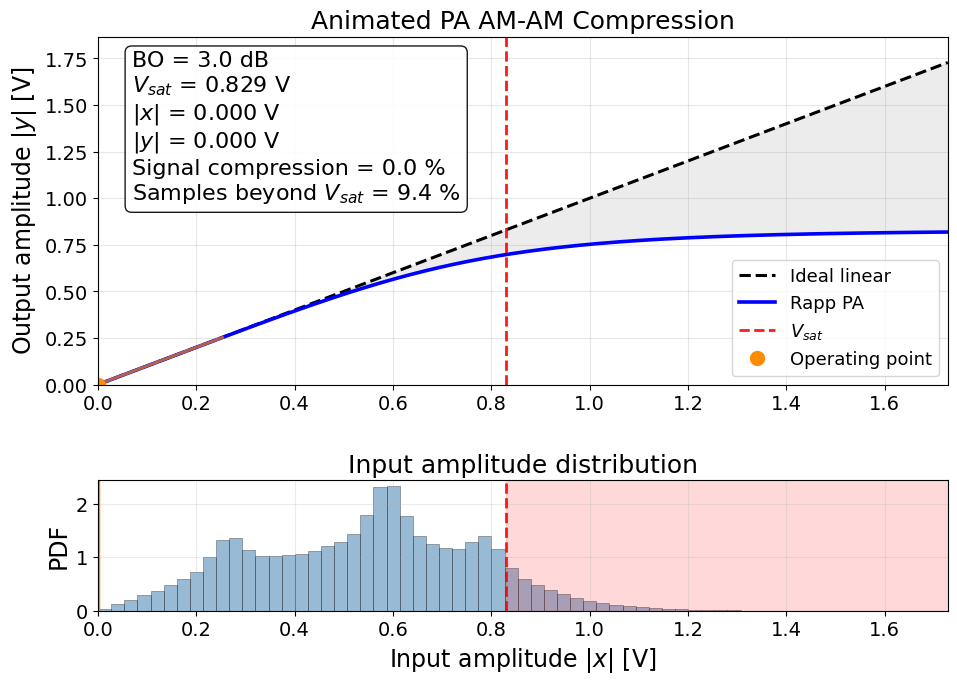

In [ ]:
def animate_pa_am_am_compression(sigTx, mzmScale, Vpi,
                                 BO_dB=5.0, p=2.0,
                                 gif_name='pa_amam_animation.gif',
                                 fps=12,
                                 interval_ms=80,
                                 n_cycles=2,
                                 n_sweep_points=220,
                                 show_hist=True):
    """
    Animated AM-AM compression of the PA.
    Saves the GIF in the current working directory.
    """

    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation, PillowWriter
    from matplotlib.animation import FFMpegWriter

    plt.rcParams.update({
        'font.size': 16,
        'axes.titlesize': 18,
        'axes.labelsize': 17,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 13
    })

    # ------------------------------------------------------------
    # 1) Reproduce your PA input scaling
    # ------------------------------------------------------------
    target_peak_V = mzmScale * Vpi
    peak_sigTx = np.max(np.abs(sigTx))

    if peak_sigTx == 0:
        raise ValueError("sigTx peak is zero; cannot build PA animation.")

    gain_linear = target_peak_V / peak_sigTx
    x_amp = gain_linear * sigTx

    Ain_samples = np.abs(x_amp)
    Vrms_in = np.sqrt(np.mean(np.abs(x_amp) ** 2))
    Vsat = Vrms_in * 10 ** (BO_dB / 20)

    # Percentage of samples beyond saturation
    percent_compressed = np.mean(Ain_samples > Vsat) * 100

    # ------------------------------------------------------------
    # 2) AM-AM mapping from the same Rapp model
    # ------------------------------------------------------------
    def rapp_amam(a, Vsat, p):
        return a / (1.0 + (a / Vsat) ** (2 * p)) ** (1.0 / (2 * p))

    a_min = 0.0
    a_max = np.max(Ain_samples)

    forward = np.linspace(a_min, a_max, n_sweep_points)
    backward = np.linspace(a_max, a_min, n_sweep_points)
    one_cycle = np.concatenate([forward, backward])
    sweep = np.tile(one_cycle, n_cycles)

    a_axis = np.linspace(0, 1.08 * a_max, 1200)
    y_rapp = rapp_amam(a_axis, Vsat, p)
    y_ideal = a_axis

    # ------------------------------------------------------------
    # 3) Figure layout: fixed spacing so plots do not overlap
    # ------------------------------------------------------------
    if show_hist:
        fig = plt.figure(figsize=(10, 7))
        gs = fig.add_gridspec(
            2, 1,
            height_ratios=[3.2, 1.2],
            hspace=0.40
        )
        ax = fig.add_subplot(gs[0])
        ax_hist = fig.add_subplot(gs[1], sharex=ax)

        fig.subplots_adjust(
            left=0.10,
            right=0.95,
            top=0.92,
            bottom=0.10
        )
    else:
        fig, ax = plt.subplots(figsize=(10, 5.8))
        fig.subplots_adjust(
            left=0.10,
            right=0.95,
            top=0.90,
            bottom=0.12
        )
        ax_hist = None

    # ------------------------------------------------------------
    # 4) Main AM-AM plot
    # ------------------------------------------------------------
    ax.plot(a_axis, y_ideal, 'k--', linewidth=2.2, label='Ideal linear')
    ax.plot(a_axis, y_rapp, color='blue', linewidth=2.6, label='Rapp PA')
    ax.axvline(Vsat, color='red', linestyle='--', linewidth=2, alpha=0.9, label=r'$V_{sat}$')

    point, = ax.plot([], [], 'o', color='darkorange', markersize=10, label='Operating point')
    trail, = ax.plot([], [], color='darkorange', linewidth=2.2, alpha=0.7)

    ax.fill_between(a_axis, y_rapp, y_ideal, where=(y_ideal >= y_rapp),
                    alpha=0.15, color='gray')

    text_box = ax.text(
        0.04, 0.96, "",
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black')
    )

    ax.set_title('Animated PA AM-AM Compression')
    ax.set_xlabel("")
    ax.set_ylabel('Output amplitude $|y|$ [V]')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1.08 * a_max)
    ax.set_ylim(0, 1.08 * np.max(y_ideal))
    ax.legend(loc='lower right')

    # ------------------------------------------------------------
    # 5) Histogram panel
    # ------------------------------------------------------------
    hist_line = None

    if show_hist:
        ax_hist.hist(
            Ain_samples,
            bins=60,
            density=True,
            alpha=0.55,
            color='steelblue',
            edgecolor='black',
            linewidth=0.4
        )

        ax_hist.axvspan(Vsat, 1.08 * a_max, alpha=0.15, color='red')
        hist_line = ax_hist.axvline(0, color='darkorange', linewidth=2.5)
        ax_hist.axvline(Vsat, color='red', linestyle='--', linewidth=2, alpha=0.9)

        ax_hist.set_title('Input amplitude distribution')
        ax_hist.set_xlabel('Input amplitude $|x|$ [V]')
        ax_hist.set_ylabel('PDF')
        ax_hist.grid(True, alpha=0.25)

    # ------------------------------------------------------------
    # 6) Animation
    # ------------------------------------------------------------
    tail = 22

    def init():
        point.set_data([], [])
        trail.set_data([], [])
        text_box.set_text("")
        if hist_line is not None:
            hist_line.set_xdata([0, 0])
            return point, trail, text_box, hist_line
        return point, trail, text_box

    def update(frame):
        a_in = sweep[frame]
        a_out = rapp_amam(a_in, Vsat, p)

        point.set_data([a_in], [a_out])

        start = max(0, frame - tail)
        trail_in = sweep[start:frame+1]
        trail_out = rapp_amam(trail_in, Vsat, p)
        trail.set_data(trail_in, trail_out)

        if a_in > 1e-12:
            gain_inst = a_out / a_in
            comp_pct_inst = (1 - gain_inst) * 100
        else:
            comp_pct_inst = 0.0

        text_box.set_text(
            f"BO = {BO_dB:.1f} dB\n"
            f"$V_{{sat}}$ = {Vsat:.3f} V\n"
            f"$|x|$ = {a_in:.3f} V\n"
            f"$|y|$ = {a_out:.3f} V\n"
            f"Signal compression = {comp_pct_inst:.1f} %\n"
            f"Samples beyond $V_{{sat}}$ = {percent_compressed:.1f} %"
        )

        artists = [point, trail, text_box]

        if hist_line is not None:
            hist_line.set_xdata([a_in, a_in])
            artists.append(hist_line)

        return tuple(artists)

    ani = FuncAnimation(
        fig,
        update,
        frames=len(sweep),
        init_func=init,
        blit=True,
        interval=interval_ms
    )

    # Save in current working directory
    gif_path = gif_name
    print("Saving to:", os.getcwd())
    print("Filename:", gif_path)

    ani.save(gif_path, writer=PillowWriter(fps=fps))
    ani.save("pa_amam.mp4", writer=FFMpegWriter(fps=10))

    plt.show()
    return ani

ani_pa = animate_pa_am_am_compression(
    sigTx=sigTx,
    mzmScale=0.8,
    Vpi=paramIQM.Vpi,
    BO_dB=3,
    p=PA_p,
    gif_name='pa_amam_compression.gif',
    fps=10,
    interval_ms=70,
    n_cycles=1,
    n_sweep_points=140,
    show_hist=True
)